In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_oil_spill(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Slightly blur to reduce speckle noise
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Oil spills appear as darker patches - threshold to isolate them
    _, thresh = cv2.threshold(blurred, 90, 255, cv2.THRESH_BINARY_INV)
    
    # Clean up small noise
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    
    # Find contours (the spill boundaries)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    spill_contours = [c for c in contours if cv2.contourArea(c) > 30]
    
    # Draw red outlines on the original image
    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(output, spill_contours, -1, (0, 0, 255), 2)
    
    return output, spill_contours, cleaned

# Path to your image
image_path = "data/class_1_01780.jpg"

result, contours, mask = detect_oil_spill(image_path)

# Display original, mask, and result side by side
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Detected Dark Regions")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Spill Highlighted")
plt.axis('off')

plt.show()

print(f"Number of spill regions detected: {len(contours)}")
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    print(f"  Region {i+1}: approx {area:.0f} pixels")

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\smooth.dispatch.cpp:534: error: (-215:Assertion failed) !_src.empty() in function 'cv::GaussianBlur'


In [3]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\itshm
['.android', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'fastapi-project', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{25669f7a-9201-11f1-80bd-c92edd8cc936}.TM.blf', 'NTUSER.DAT{25669f7a-9201-11f1-80bd-c92edd8cc936}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{25669f7a-9201-11f1-80bd-c92edd8cc936}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'orca_engine1.ipynb', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Videos']


In [4]:
import os
print(os.listdir("data"))

['Class_0', 'class_1_00001.jpg', 'class_1_00002.jpg', 'class_1_00003.jpg', 'class_1_00004.jpg', 'class_1_00005.jpg', 'class_1_00006.jpg', 'class_1_00007.jpg', 'class_1_00008.jpg', 'class_1_00009.jpg', 'class_1_00010.jpg', 'class_1_00011.jpg', 'class_1_00012.jpg', 'class_1_00013.jpg', 'class_1_00014.jpg', 'class_1_00015.jpg', 'class_1_00016.jpg', 'class_1_00017.jpg', 'class_1_00018.jpg', 'class_1_00019.jpg', 'class_1_00020.jpg', 'class_1_00021.jpg', 'class_1_00022.jpg', 'class_1_00023.jpg', 'class_1_00024.jpg', 'class_1_00025.jpg', 'class_1_00026.jpg', 'class_1_00027.jpg', 'class_1_00028.jpg', 'class_1_00029.jpg', 'class_1_00030.jpg', 'class_1_00031.jpg', 'class_1_00032.jpg', 'class_1_00033.jpg', 'class_1_00034.jpg', 'class_1_00035.jpg', 'class_1_00036.jpg', 'class_1_00037.jpg', 'class_1_00038.jpg', 'class_1_00039.jpg', 'class_1_00040.jpg', 'class_1_00041.jpg', 'class_1_00042.jpg', 'class_1_00043.jpg', 'class_1_00044.jpg', 'class_1_00045.jpg', 'class_1_00046.jpg', 'class_1_00047.jpg', '

In [5]:
print(os.listdir("data"))

['Class_0', 'class_1_00001.jpg', 'class_1_00002.jpg', 'class_1_00003.jpg', 'class_1_00004.jpg', 'class_1_00005.jpg', 'class_1_00006.jpg', 'class_1_00007.jpg', 'class_1_00008.jpg', 'class_1_00009.jpg', 'class_1_00010.jpg', 'class_1_00011.jpg', 'class_1_00012.jpg', 'class_1_00013.jpg', 'class_1_00014.jpg', 'class_1_00015.jpg', 'class_1_00016.jpg', 'class_1_00017.jpg', 'class_1_00018.jpg', 'class_1_00019.jpg', 'class_1_00020.jpg', 'class_1_00021.jpg', 'class_1_00022.jpg', 'class_1_00023.jpg', 'class_1_00024.jpg', 'class_1_00025.jpg', 'class_1_00026.jpg', 'class_1_00027.jpg', 'class_1_00028.jpg', 'class_1_00029.jpg', 'class_1_00030.jpg', 'class_1_00031.jpg', 'class_1_00032.jpg', 'class_1_00033.jpg', 'class_1_00034.jpg', 'class_1_00035.jpg', 'class_1_00036.jpg', 'class_1_00037.jpg', 'class_1_00038.jpg', 'class_1_00039.jpg', 'class_1_00040.jpg', 'class_1_00041.jpg', 'class_1_00042.jpg', 'class_1_00043.jpg', 'class_1_00044.jpg', 'class_1_00045.jpg', 'class_1_00046.jpg', 'class_1_00047.jpg', '

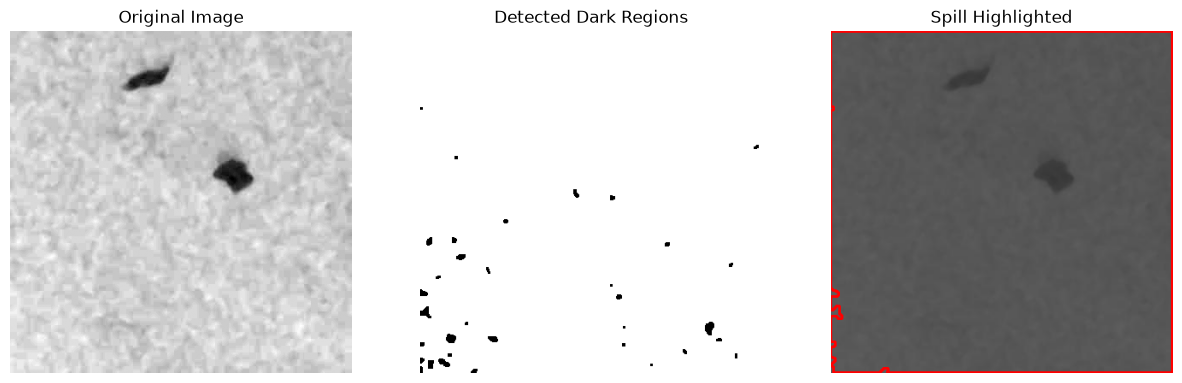

Number of spill regions detected: 1
  Region 1: approx 158900 pixels


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_oil_spill(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Slightly blur to reduce speckle noise
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Oil spills appear as darker patches - threshold to isolate them
    _, thresh = cv2.threshold(blurred, 90, 255, cv2.THRESH_BINARY_INV)
    
    # Clean up small noise
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    
    # Find contours (the spill boundaries)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    spill_contours = [c for c in contours if cv2.contourArea(c) > 30]
    
    # Draw red outlines on the original image
    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(output, spill_contours, -1, (0, 0, 255), 2)
    
    return output, spill_contours, cleaned

# Path to your image
image_path = "data/class_1_01780.jpg"

result, contours, mask = detect_oil_spill(image_path)

# Display original, mask, and result side by side
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Detected Dark Regions")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Spill Highlighted")
plt.axis('off')

plt.show()

print(f"Number of spill regions detected: {len(contours)}")
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    print(f"  Region {i+1}: approx {area:.0f} pixels")

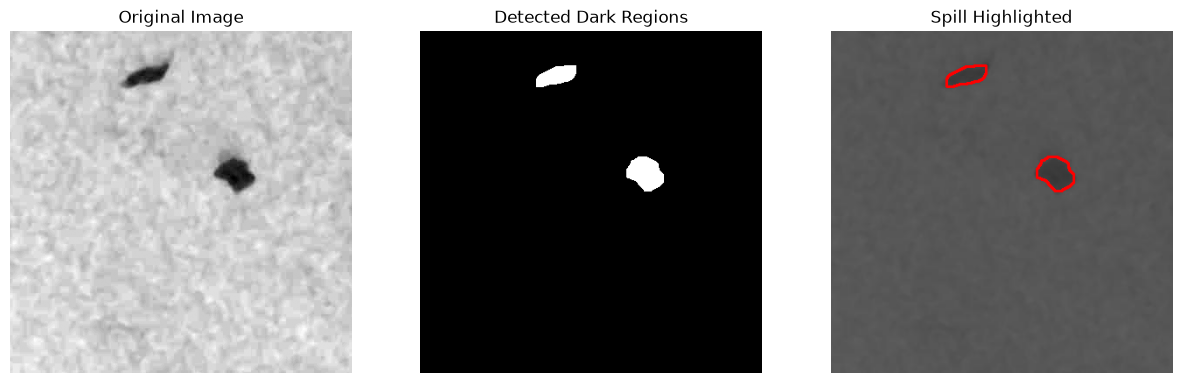

Number of spill regions detected: 2
  Region 1: approx 1150 pixels
  Region 2: approx 736 pixels


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_oil_spill(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Crop a small margin off the edges to avoid border artifacts
    margin = 5
    img = img[margin:-margin, margin:-margin]
    
    # Stronger blur to smooth out speckle noise
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    
    # Use Otsu's method - automatically picks the best threshold instead of a fixed guess
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Stronger cleanup to remove small noise specks
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Higher minimum area - filters out tiny noise blobs, keeps real spill patches
    spill_contours = [c for c in contours if 100 < cv2.contourArea(c) < 20000]
    
    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(output, spill_contours, -1, (0, 0, 255), 2)
    
    return output, spill_contours, cleaned, img

image_path = "data/class_1_01780.jpg"
result, contours, mask, cropped_original = detect_oil_spill(image_path)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cropped_original, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Detected Dark Regions")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Spill Highlighted")
plt.axis('off')

plt.show()

print(f"Number of spill regions detected: {len(contours)}")
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    print(f"  Region {i+1}: approx {area:.0f} pixels")

In [8]:
def calculate_spill_properties(contours, image_shape, resolution_m_per_pixel=10):
    """
    Calculates real-world area and shape properties for each detected spill.
    resolution_m_per_pixel: Sentinel-1 SAR typically has ~10m ground resolution per pixel.
    """
    properties = []
    
    for i, c in enumerate(contours):
        pixel_area = cv2.contourArea(c)
        
        # Convert pixel area to real-world area (square meters, then km²)
        area_sq_m = pixel_area * (resolution_m_per_pixel ** 2)
        area_sq_km = area_sq_m / 1_000_000
        
        # Perimeter (boundary length)
        perimeter_pixels = cv2.arcLength(c, True)
        perimeter_m = perimeter_pixels * resolution_m_per_pixel
        
        # Elongation ratio - helps distinguish fresh (compact) vs older (spread out) spills
        if perimeter_pixels > 0:
            elongation_ratio = (perimeter_pixels ** 2) / (4 * np.pi * pixel_area) if pixel_area > 0 else 0
        else:
            elongation_ratio = 0
        
        # Simple heuristic for age category based on elongation
        if elongation_ratio < 1.5:
            age_estimate = "Likely fresh (compact shape)"
        elif elongation_ratio < 3:
            age_estimate = "Moderately spread (some hours old)"
        else:
            age_estimate = "Likely older / wind-driven (elongated shape)"
        
        properties.append({
            "region": i + 1,
            "area_sq_km": round(area_sq_km, 4),
            "perimeter_m": round(perimeter_m, 1),
            "elongation_ratio": round(elongation_ratio, 2),
            "age_estimate": age_estimate
        })
    
    return properties

# Run this on the contours we already detected
spill_properties = calculate_spill_properties(contours, mask.shape)

print("=== Spill Characterization Report ===\n")
for prop in spill_properties:
    print(f"Region {prop['region']}:")
    print(f"  Estimated Area: {prop['area_sq_km']} km²")
    print(f"  Perimeter: {prop['perimeter_m']} meters")
    print(f"  Elongation Ratio: {prop['elongation_ratio']}")
    print(f"  Age Estimate: {prop['age_estimate']}")
    print()

=== Spill Characterization Report ===

Region 1:
  Estimated Area: 0.115 km²
  Perimeter: 1338.8 meters
  Elongation Ratio: 1.24
  Age Estimate: Likely fresh (compact shape)

Region 2:
  Estimated Area: 0.0736 km²
  Perimeter: 1221.8 meters
  Elongation Ratio: 1.62
  Age Estimate: Moderately spread (some hours old)



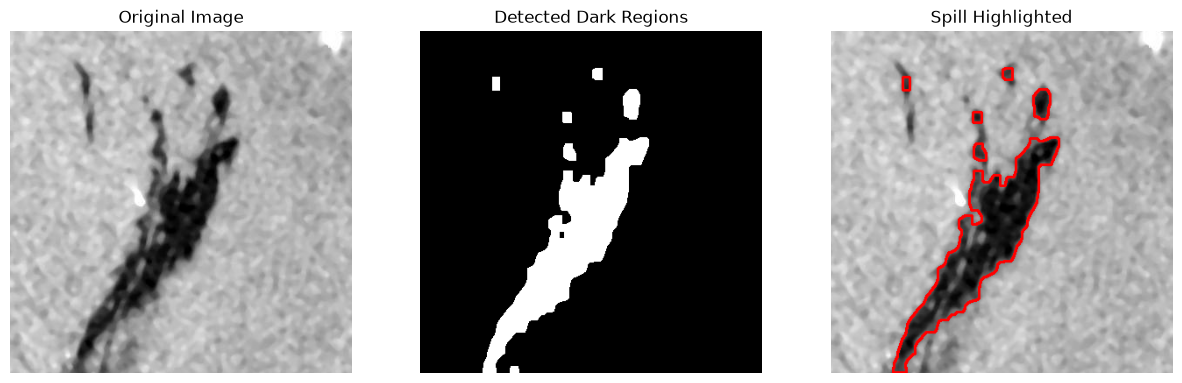

Number of spill regions detected: 6
  Region 1: approx 219 pixels
  Region 2: approx 13332 pixels
  Region 3: approx 119 pixels
  Region 4: approx 542 pixels
  Region 5: approx 120 pixels
  Region 6: approx 136 pixels


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_oil_spill(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Crop a small margin off the edges to avoid border artifacts
    margin = 5
    img = img[margin:-margin, margin:-margin]
    
    # Stronger blur to smooth out speckle noise
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    
    # Use Otsu's method - automatically picks the best threshold instead of a fixed guess
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Stronger cleanup to remove small noise specks
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    # Find contours
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Higher minimum area - filters out tiny noise blobs, keeps real spill patches
    spill_contours = [c for c in contours if 100 < cv2.contourArea(c) < 20000]
    
    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(output, spill_contours, -1, (0, 0, 255), 2)
    
    return output, spill_contours, cleaned, img

image_path = "data/class_1_00361.jpg"
result, contours, mask, cropped_original = detect_oil_spill(image_path)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cropped_original, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Detected Dark Regions")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Spill Highlighted")
plt.axis('off')

plt.show()

print(f"Number of spill regions detected: {len(contours)}")
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    print(f"  Region {i+1}: approx {area:.0f} pixels")

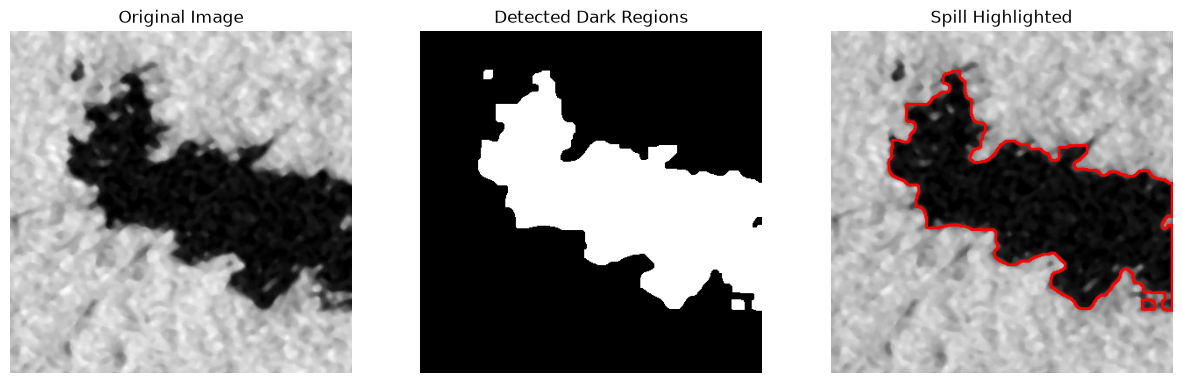

=== Spill Characterization Report ===

Number of spill regions detected: 2

Region 1:
  Estimated Area: 0.0149 km²
  Perimeter: 482.4 meters
  Elongation Ratio: 1.25
  Age Estimate: Likely fresh (compact shape)

Region 2:
  Estimated Area: 4.1239 km²
  Perimeter: 13971.8 meters
  Elongation Ratio: 3.77
  Age Estimate: Likely older / wind-driven (elongated shape)



In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_oil_spill(image_path, resolution_m_per_pixel=10):
    # ---- DETECTION ----
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    margin = 5
    img = img[margin:-margin, margin:-margin]
    
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((5,5), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=1)
    
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    spill_contours = [c for c in contours if cv2.contourArea(c) > 100]
    
    output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(output, spill_contours, -1, (0, 0, 255), 2)
    
    # ---- DISPLAY IMAGES ----
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(cleaned, cmap='gray')
    plt.title("Detected Dark Regions")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Spill Highlighted")
    plt.axis('off')
    
    plt.show()
    
    # ---- CHARACTERIZATION (AREA, ETC.) ----
    print("=== Spill Characterization Report ===\n")
    print(f"Number of spill regions detected: {len(spill_contours)}\n")
    
    for i, c in enumerate(spill_contours):
        pixel_area = cv2.contourArea(c)
        area_sq_km = (pixel_area * (resolution_m_per_pixel ** 2)) / 1_000_000
        perimeter_pixels = cv2.arcLength(c, True)
        perimeter_m = perimeter_pixels * resolution_m_per_pixel
        elongation_ratio = (perimeter_pixels ** 2) / (4 * np.pi * pixel_area) if pixel_area > 0 else 0
        
        if elongation_ratio < 1.5:
            age_estimate = "Likely fresh (compact shape)"
        elif elongation_ratio < 3:
            age_estimate = "Moderately spread (some hours old)"
        else:
            age_estimate = "Likely older / wind-driven (elongated shape)"
        
        print(f"Region {i+1}:")
        print(f"  Estimated Area: {round(area_sq_km, 4)} km²")
        print(f"  Perimeter: {round(perimeter_m, 1)} meters")
        print(f"  Elongation Ratio: {round(elongation_ratio, 2)}")
        print(f"  Age Estimate: {age_estimate}")
        print()
    
    return spill_contours


# ---- RUN IT ----
analyze_oil_spill("data/class_1_00513.jpg");

In [14]:
import pandas as pd

# Synthetic AIS-style ship data near a hypothetical spill location
ships_data = {
    "ship_name": ["MV Horizon", "SS Coral Queen", "MV Deccan Trader", "MT Sagar Prince", "MV Bay Runner"],
    "ship_type": ["Oil Tanker", "Passenger Ferry", "Cargo Ship", "Oil Tanker", "Cargo Ship"],
    "distance_from_spill_km": [2.1, 18.5, 6.4, 3.8, 25.0],
    "speed_knots": [4.2, 16.0, 12.5, 3.0, 14.2],
    "ais_signal_gap": [True, False, False, True, False],
    "trajectory_match": [0.85, 0.20, 0.55, 0.90, 0.10]
}

ships_df = pd.DataFrame(ships_data)
print(ships_df)

ModuleNotFoundError: No module named 'pandas'

In [16]:
!pip install pandas

In [17]:
import pandas as pd

ships_data = {
    "ship_name": ["MV Horizon", "SS Coral Queen", "MV Deccan Trader", "MT Sagar Prince", "MV Bay Runner"],
    "ship_type": ["Oil Tanker", "Passenger Ferry", "Cargo Ship", "Oil Tanker", "Cargo Ship"],
    "distance_from_spill_km": [2.1, 18.5, 6.4, 3.8, 25.0],
    "speed_knots": [4.2, 16.0, 12.5, 3.0, 14.2],
    "ais_signal_gap": [True, False, False, True, False],
    "trajectory_match": [0.85, 0.20, 0.55, 0.90, 0.10]
}

ships_df = pd.DataFrame(ships_data)
print(ships_df)

          ship_name        ship_type  distance_from_spill_km  speed_knots  \
0        MV Horizon       Oil Tanker                     2.1          4.2   
1    SS Coral Queen  Passenger Ferry                    18.5         16.0   
2  MV Deccan Trader       Cargo Ship                     6.4         12.5   
3   MT Sagar Prince       Oil Tanker                     3.8          3.0   
4     MV Bay Runner       Cargo Ship                    25.0         14.2   

   ais_signal_gap  trajectory_match  
0            True              0.85  
1           False              0.20  
2           False              0.55  
3            True              0.90  
4           False              0.10  


In [19]:
def calculate_suspect_score(row):
    score = 0
    
    # 1. Proximity - closer to spill = more suspicious (max 35 points)
    if row['distance_from_spill_km'] <= 5:
        score += 35
    elif row['distance_from_spill_km'] <= 10:
        score += 20
    elif row['distance_from_spill_km'] <= 20:
        score += 10
    else:
        score += 0
    
    # 2. AIS signal gap - going dark is a major red flag (max 30 points)
    if row['ais_signal_gap']:
        score += 30
    
    # 3. Trajectory match - does its path align with the spill's drift? (max 25 points)
    score += row['trajectory_match'] * 25
    
    # 4. Vessel type risk - tankers carry oil, higher inherent risk (max 10 points)
    if row['ship_type'] == "Oil Tanker":
        score += 10
    elif row['ship_type'] == "Cargo Ship":
        score += 5
    else:
        score += 0
    
    return round(score, 1)


# Apply scoring to every ship
ships_df['suspect_score'] = ships_df.apply(calculate_suspect_score, axis=1)

# Sort by score, highest suspicion first
ranked_ships = ships_df.sort_values(by='suspect_score', ascending=False).reset_index(drop=True)

print("=== Vessel Attribution Report ===\n")
print(ranked_ships[['ship_name', 'ship_type', 'distance_from_spill_km', 'ais_signal_gap', 'suspect_score']])

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("=== Vessel Attribution Report ===\n")
print(ranked_ships[['ship_name', 'ship_type', 'distance_from_spill_km', 'ais_signal_gap', 'suspect_score']])

=== Vessel Attribution Report ===

          ship_name        ship_type  distance_from_spill_km  ais_signal_gap  \
0   MT Sagar Prince       Oil Tanker                     3.8            True   
1        MV Horizon       Oil Tanker                     2.1            True   
2  MV Deccan Trader       Cargo Ship                     6.4           False   
3    SS Coral Queen  Passenger Ferry                    18.5           False   
4     MV Bay Runner       Cargo Ship                    25.0           False   

   suspect_score  
0           97.5  
1           96.2  
2           38.8  
3           15.0  
4            7.5  
=== Vessel Attribution Report ===

          ship_name        ship_type  distance_from_spill_km  ais_signal_gap  suspect_score
0   MT Sagar Prince       Oil Tanker                     3.8            True           97.5
1        MV Horizon       Oil Tanker                     2.1            True           96.2
2  MV Deccan Trader       Cargo Ship                     6.

In [20]:
# Synthetic ocean current and wind data near the spill location
# In a real system, this would come from Copernicus Marine Service / NOAA APIs

spill_current_lat = 15.2993   # example spill location (latitude)
spill_current_lon = 74.1240   # example spill location (longitude)

current_speed_kmph = 1.5      # ocean current speed
current_direction_deg = 45    # direction current is flowing TOWARD (0=North, 90=East, etc.)

wind_speed_kmph = 3.0
wind_direction_deg = 60
wind_drift_factor = 0.03      # oil typically drifts at ~3% of wind speed

print("Spill Location:", spill_current_lat, spill_current_lon)
print("Current: ", current_speed_kmph, "km/h at", current_direction_deg, "degrees")
print("Wind: ", wind_speed_kmph, "km/h at", wind_direction_deg, "degrees")

Spill Location: 15.2993 74.124
Current:  1.5 km/h at 45 degrees
Wind:  3.0 km/h at 60 degrees


In [21]:
import math

def calculate_drift_position(start_lat, start_lon, current_speed_kmph, current_dir_deg,
                               wind_speed_kmph, wind_dir_deg, wind_drift_factor, 
                               hours, direction="forward"):
    """
    Calculates a new position after drifting for a given number of hours.
    direction: "forward" predicts future position, "backward" estimates origin.
    """
    # Combine current and wind-driven drift into one effective velocity
    # Convert direction degrees to radians (0 = North, measured clockwise)
    current_rad = math.radians(current_dir_deg)
    wind_rad = math.radians(wind_dir_deg)
    
    # Effective drift components (current + a fraction of wind speed)
    effective_speed_x = (current_speed_kmph * math.sin(current_rad)) + \
                         (wind_speed_kmph * wind_drift_factor * math.sin(wind_rad))
    effective_speed_y = (current_speed_kmph * math.cos(current_rad)) + \
                         (wind_speed_kmph * wind_drift_factor * math.cos(wind_rad))
    
    # If calculating backward (origin), reverse the direction of travel
    if direction == "backward":
        effective_speed_x *= -1
        effective_speed_y *= -1
    
    # Distance traveled in km over the given hours
    distance_x_km = effective_speed_x * hours
    distance_y_km = effective_speed_y * hours
    
    # Convert km displacement to approximate lat/lon change
    # 1 degree latitude ≈ 111 km ; 1 degree longitude ≈ 111 km * cos(latitude)
    delta_lat = distance_y_km / 111.0
    delta_lon = distance_x_km / (111.0 * math.cos(math.radians(start_lat)))
    
    new_lat = start_lat + delta_lat
    new_lon = start_lon + delta_lon
    
    return round(new_lat, 5), round(new_lon, 5)


# ---- Estimate ORIGIN (backward, e.g. 6 hours before detection) ----
origin_lat, origin_lon = calculate_drift_position(
    spill_current_lat, spill_current_lon,
    current_speed_kmph, current_direction_deg,
    wind_speed_kmph, wind_direction_deg, wind_drift_factor,
    hours=6, direction="backward"
)

# ---- Predict FUTURE position (forward, e.g. 12 hours ahead) ----
future_lat, future_lon = calculate_drift_position(
    spill_current_lat, spill_current_lon,
    current_speed_kmph, current_direction_deg,
    wind_speed_kmph, wind_direction_deg, wind_drift_factor,
    hours=12, direction="forward"
)

print("=== Drift Analysis Report ===\n")
print(f"Detected Spill Position:  ({spill_current_lat}, {spill_current_lon})")
print(f"Estimated Origin (6 hrs prior):  ({origin_lat}, {origin_lon})")
print(f"Predicted Position (12 hrs ahead): ({future_lat}, {future_lon})")

=== Drift Analysis Report ===

Detected Spill Position:  (15.2993, 74.124)
Estimated Origin (6 hrs prior):  (15.23953, 74.06019)
Predicted Position (12 hrs ahead): (15.41883, 74.25161)


PROJECT ORCA - FULL PIPELINE EXECUTION

[ENGINE 1] Running Detection & Characterization...



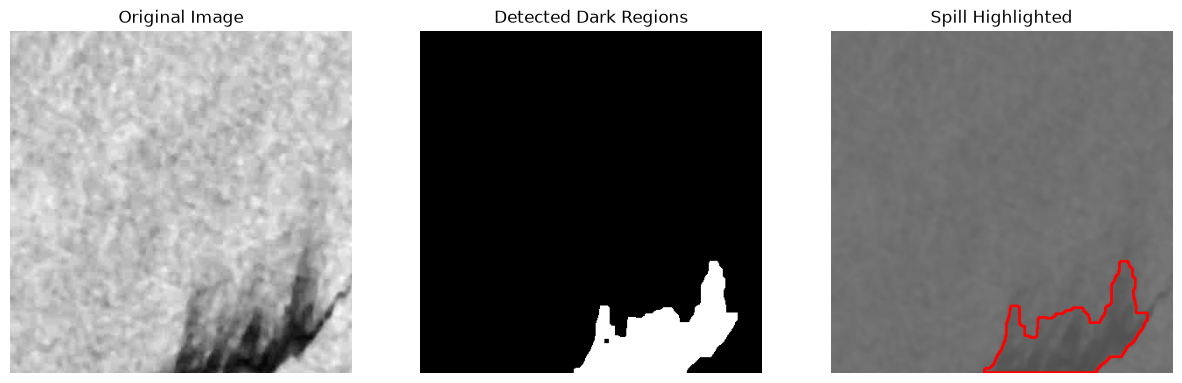

=== Spill Characterization Report ===

Number of spill regions detected: 1

Region 1:
  Estimated Area: 1.061 km²
  Perimeter: 6559.9 meters
  Elongation Ratio: 3.23
  Age Estimate: Likely older / wind-driven (elongated shape)

Primary spill selected for tracking. Area: 1.061 km²

[ENGINE 2] Running Hindcast & Forecast...

Detected Position:        (15.2993, 74.124)
Estimated Origin (6h prior): (15.23953, 74.06019)
Predicted Position (12h ahead): (15.41883, 74.25161)

[ENGINE 3] Running Vessel Attribution...

          ship_name        ship_type  distance_from_spill_km  ais_signal_gap  suspect_score
0   MT Sagar Prince       Oil Tanker                     3.8            True           97.5
1        MV Horizon       Oil Tanker                     2.1            True           96.2
2  MV Deccan Trader       Cargo Ship                     6.4           False           38.8
3    SS Coral Queen  Passenger Ferry                    18.5           False           15.0
4     MV Bay Runner      

In [24]:
def run_orca_pipeline(image_path, current_speed_kmph, current_direction_deg,
                       wind_speed_kmph, wind_direction_deg, wind_drift_factor,
                       spill_lat, spill_lon, ships_df):
    """
    Full ORCA pipeline: Detection -> Drift Analysis -> Attribution
    """
    print("=" * 60)
    print("PROJECT ORCA - FULL PIPELINE EXECUTION")
    print("=" * 60)
    
    # ---------------- ENGINE 1: DETECTION ----------------
    print("\n[ENGINE 1] Running Detection & Characterization...\n")
    spill_contours = analyze_oil_spill(image_path)
    
    if len(spill_contours) == 0:
        print("No spill detected. Pipeline stopped.")
        return None
    
    # Use the largest detected spill for further analysis
    largest_spill = max(spill_contours, key=cv2.contourArea)
    largest_area_km2 = (cv2.contourArea(largest_spill) * 100) / 1_000_000
    print(f"Primary spill selected for tracking. Area: {round(largest_area_km2, 4)} km²")
    
    # ---------------- ENGINE 2: DRIFT ANALYSIS ----------------
    print("\n[ENGINE 2] Running Hindcast & Forecast...\n")
    
    origin_lat, origin_lon = calculate_drift_position(
        spill_lat, spill_lon,
        current_speed_kmph, current_direction_deg,
        wind_speed_kmph, wind_direction_deg, wind_drift_factor,
        hours=6, direction="backward"
    )
    
    future_lat, future_lon = calculate_drift_position(
        spill_lat, spill_lon,
        current_speed_kmph, current_direction_deg,
        wind_speed_kmph, wind_direction_deg, wind_drift_factor,
        hours=12, direction="forward"
    )
    
    print(f"Detected Position:        ({spill_lat}, {spill_lon})")
    print(f"Estimated Origin (6h prior): ({origin_lat}, {origin_lon})")
    print(f"Predicted Position (12h ahead): ({future_lat}, {future_lon})")
    
    # ---------------- ENGINE 3: ATTRIBUTION ----------------
    print("\n[ENGINE 3] Running Vessel Attribution...\n")
    
    ships_df = ships_df.copy()
    ships_df['suspect_score'] = ships_df.apply(calculate_suspect_score, axis=1)
    ranked_ships = ships_df.sort_values(by='suspect_score', ascending=False).reset_index(drop=True)
    
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_columns', None)
    print(ranked_ships[['ship_name', 'ship_type', 'distance_from_spill_km', 'ais_signal_gap', 'suspect_score']])
    
    # ---------------- FINAL SUMMARY ----------------
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    top_suspect = ranked_ships.iloc[0]
    print(f"Spill Area: {round(largest_area_km2, 4)} km²")
    print(f"Estimated Origin: ({origin_lat}, {origin_lon})")
    print(f"Top Suspect Vessel: {top_suspect['ship_name']} (Score: {top_suspect['suspect_score']})")
    print("=" * 60)
    
    return {
        "spill_area_km2": largest_area_km2,
        "origin": (origin_lat, origin_lon),
        "future_position": (future_lat, future_lon),
        "ranked_ships": ranked_ships
    }


# ---- RUN THE FULL PIPELINE ----
results = run_orca_pipeline(
    image_path="data/class_1_00046.jpg",
    current_speed_kmph=1.5, current_direction_deg=45,
    wind_speed_kmph=3.0, wind_direction_deg=60, wind_drift_factor=0.03,
    spill_lat=15.2993, spill_lon=74.1240,
    ships_df=ships_df
)

In [25]:
!pip install streamlit folium streamlit-folium

  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached starlette-1.6.0-py3-none-any.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ------------- -------------------------- 3.7/10.5 MB 19.2 MB/s eta 0:00:01
   ----------------- ---------------------- 4.7/10.5 MB 12.3 MB/s eta 0:00:01
   -------------------- ------------------- 5.5/10.5 MB 9.1 MB/s eta 0:00:01
   ----------------------- ---------------- 6.3/10.5 MB 7.5 MB/s eta 0:00:01
   -------------------------- ------------- 7.1/10.5 MB 6.8 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.5 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.5 MB 6.4 MB/s eta 0:00:01
   -------------------------------------- - 10.2/10.5 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 5.9 MB/s  0:00:01
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   -------------------------- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
